# Deep Learning for State Poverty Rate Prediction

**Objective:** Apply deep learning methods to predict US state poverty rates using socio-economic predictors.

**Methodology:** Following the approach from the Somalia poverty study (Nature Scientific Reports 2024), we implement:
- Neural Networks with keras
- Random Forest for comparison
- Feature importance analysis
- Model performance evaluation (RMSE, R², MAE)

**Data:** State-level cross-sectional data (n=50) for 2023

## 1. Setup and Data Loading

In [135]:
# Install required packages
install.packages(c("keras3", "tidyverse", "randomForest", "caret", "MLmetrics", "gridExtra"))

library(keras3)
library(tidyverse)
library(caret)
library(MLmetrics)

trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/keras3_1.5.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/tidyverse_2.0.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/randomForest_4.7-1.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/caret_7.0-1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/MLmetrics_1.1.3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/gridExtra_2.3.1.tgz'



The downloaded binary packages are in
	/var/folders/dv/gmvbpr29383_tr9nbd5g1r9c0000gq/T//Rtmp8OIvIu/downloaded_packages


In [136]:
data <- read_csv("/Users/winniex/Desktop/WDS/Project/dataset - Sheet1 (2).csv")
# Display structure
summary(data)

Rows: 51 Columns: 31
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): State
dbl (30): pop_dens, unemploy_rate, avg_rent, apart_size, log_income, avg_wag...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


       State       pop_dens       unemploy_rate      avg_rent   
 Length   :51   Min.   :    1.0   Min.   :2.100   Min.   : 919  
 N.unique :51   1st Qu.:   47.5   1st Qu.:3.400   1st Qu.:1129  
 N.blank  : 0   Median :  106.0   Median :4.200   Median :1364  
 Min.nchar: 4   Mean   :  412.1   Mean   :4.067   Mean   :1480  
 Max.nchar:20   3rd Qu.:  226.5   3rd Qu.:4.650   3rd Qu.:1736  
                Max.   :11011.0   Max.   :6.100   Max.   :3085  
   apart_size      log_income     avg_wage_hr    log_med_home_price
 Min.   :471.0   Min.   :4.706   Min.   :24.43   Min.   :5.360     
 1st Qu.:669.5   1st Qu.:4.784   1st Qu.:29.26   1st Qu.:5.455     
 Median :698.0   Median :4.812   Median :31.21   Median :5.590     
 Mean   :690.1   Mean   :4.824   Mean   :32.40   Mean   :5.598     
 3rd Qu.:720.5   3rd Qu.:4.855   3rd Qu.:34.44   3rd Qu.:5.700     
 Max.   :766.0   Max.   :5.045   Max.   :53.37   Max.   :5.990     
 avg_live_conver  avg_live_groc   avg_live_hous    avg_live_uti  
 Mi

## 2. Data Preparation

In [137]:
# Remove State column (keep only numeric predictors and outcome)
# Outcome variable is 'poverty'
data_clean <- data %>%
  select(-State) %>%
  na.omit()

# Check final dimensions
cat("Final dataset:", nrow(data_clean), "observations,", ncol(data_clean), "variables\n")
cat("Outcome variable: poverty\n")
cat("Number of predictors:", ncol(data_clean) - 1, "\n")

Final dataset: 51 observations, 30 variables
Outcome variable: poverty
Number of predictors: 29 


In [138]:
# Train-test split (80-20)
set.seed(2026)
train_idx <- sample(1:nrow(data_clean), size = 0.8 * nrow(data_clean))

train_data <- data_clean[train_idx, ]
test_data <- data_clean[-train_idx, ]

cat("Training set:", nrow(train_data), "observations\n")
cat("Test set:", nrow(test_data), "observations\n")

Training set: 40 observations
Test set: 11 observations


In [139]:
# Separate X and y
# Outcome variable is 'poverty'
X_train <- train_data %>% select(-poverty) %>% as.matrix()
y_train <- train_data$poverty

X_test <- test_data %>% select(-poverty) %>% as.matrix()
y_test <- test_data$poverty

In [140]:

# Normalize features (standardization)
# Explicitly calling caret to ensure the function is found
preproc <- caret::preProcess(X_train, method = c("center", "scale"))
X_train_scaled <- predict(preproc, X_train)
X_test_scaled <- predict(preproc, X_test)

## 3. Neural Network Model


In [141]:
# Define neural network architecture
# Simple feedforward network with 2 hidden layers
nn_model <- keras_model_sequential() %>%
  layer_dense(units = 64, activation = "relu", input_shape = ncol(X_train_scaled)) %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 32, activation = "relu") %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 1)  # Output layer for regression

summary(nn_model)

Model: "sequential_21"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                  │ (None, 64)               │         1,920 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_42 (Dropout)              │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_64 (Dense)                  │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_43 (Dropout)              │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_65 (Dense)                  │ (None, 1)                │            33 │
└────

In [142]:
# Compile model
nn_model %>% compile(
  loss = "mse",
  optimizer = optimizer_adam(learning_rate = 0.001),
  metrics = c("mae")
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 89.0632 - mae: 9.1356 - val_loss: 70.3214 - val_mae: 8.1825
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.1211 - mae: 8.8185 - val_loss: 65.2629 - val_mae: 7.8950
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 79.7350 - mae: 8.6094 - val_loss: 60.3570 - val_mae: 7.6064
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72.9751 - mae: 8.2184 - val_loss: 55.7092 - val_mae: 7.3186
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 67.0278 - mae: 7.9172 - val_loss: 51.2611 - val_mae: 7.0282
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 65.1795 - mae: 7.7312 - val_loss: 46.9610 - val_mae: 6.7355
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.6618 - mae: 7.2170 - val_loss: 42.7642 - val_mae: 6.4337
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 55.1863 - mae: 7.1167 - val_loss: 38.7558 - val_mae: 6.1261
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 50.648

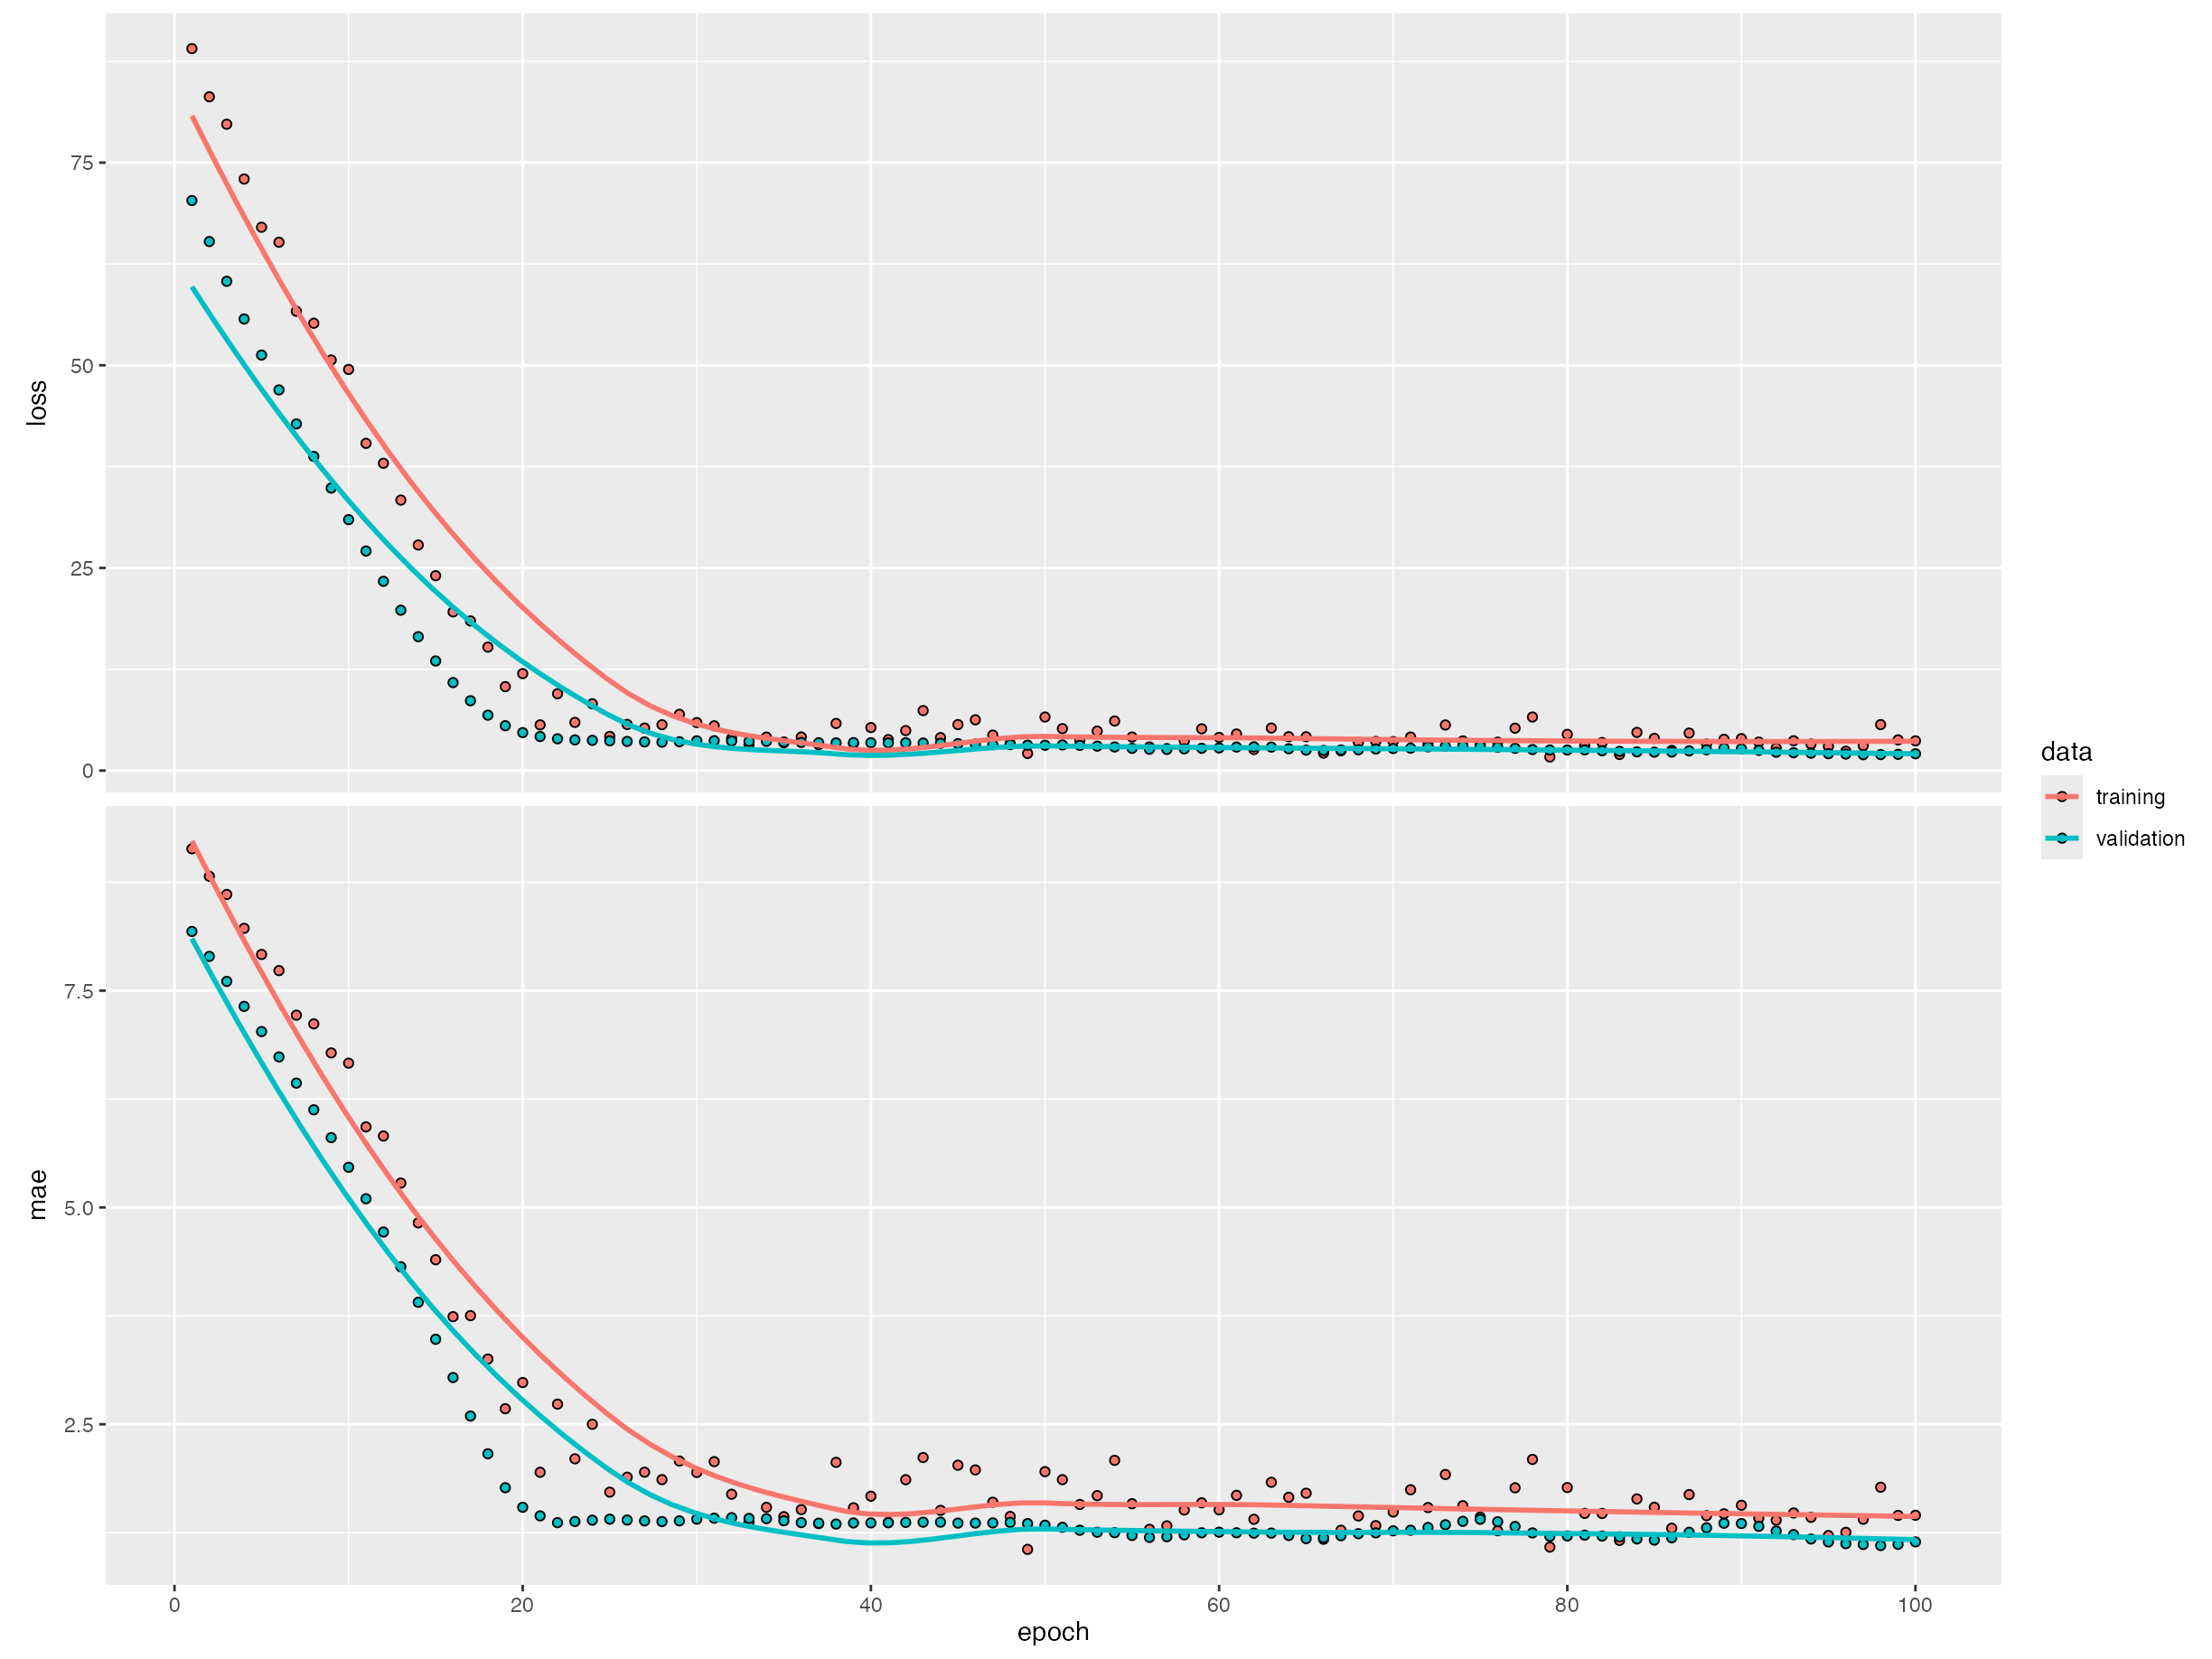

In [143]:
# Train model
history <- nn_model %>% fit(
  X_train_scaled, y_train,
  epochs = 100,
  batch_size = 8,
  validation_split = 0.2,
  verbose = 1
)

plot(history)

In [144]:
summary(nn_model)

Model: "sequential_21"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                  │ (None, 64)               │         1,920 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_42 (Dropout)              │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_64 (Dense)                  │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_43 (Dropout)              │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_65 (Dense)                  │ (None, 1)                │            33 │
└────


##4. L2 Regularization ##


In [145]:
 l2_lambda <- 0.05  # Regularization strength (can tune this)

  nn_model_l2 <- keras_model_sequential() %>%
    layer_dense(units = 64,
                activation = "relu",
                input_shape = ncol(X_train_scaled),
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 32,
                activation = "relu",
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 1,
                kernel_regularizer = regularizer_l2(l2_lambda))

  summary(nn_model_l2)

Model: "sequential_22"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                  │ (None, 64)               │         1,920 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_44 (Dropout)              │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_67 (Dense)                  │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_45 (Dropout)              │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_68 (Dense)                  │ (None, 1)                │            33 │
└────

In [146]:
  # Compile model with L2 regularization
  nn_model_l2 %>% compile(
    loss = "mse",
    optimizer = optimizer_adam(learning_rate = 0.001),
    metrics = c("mae")
  )

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 98.0005 - mae: 9.3591 - val_loss: 77.6060 - val_mae: 8.3749
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 90.9086 - mae: 9.0227 - val_loss: 72.5091 - val_mae: 8.0778
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 84.1324 - mae: 8.6698 - val_loss: 67.6213 - val_mae: 7.7866
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.7077 - mae: 8.6061 - val_loss: 62.9643 - val_mae: 7.5000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 73.8452 - mae: 8.0612 - val_loss: 58.5191 - val_mae: 7.2138
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 74.8638 - mae: 8.0909 - val_loss: 54.4718 - val_mae: 6.9387
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 66.5341 - mae: 7.6282 - val_loss: 50.6735 - val_mae: 6.6699
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 64.9377 - mae: 7.4333 - val_loss: 47.0758 - val_mae: 6.4049
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.523

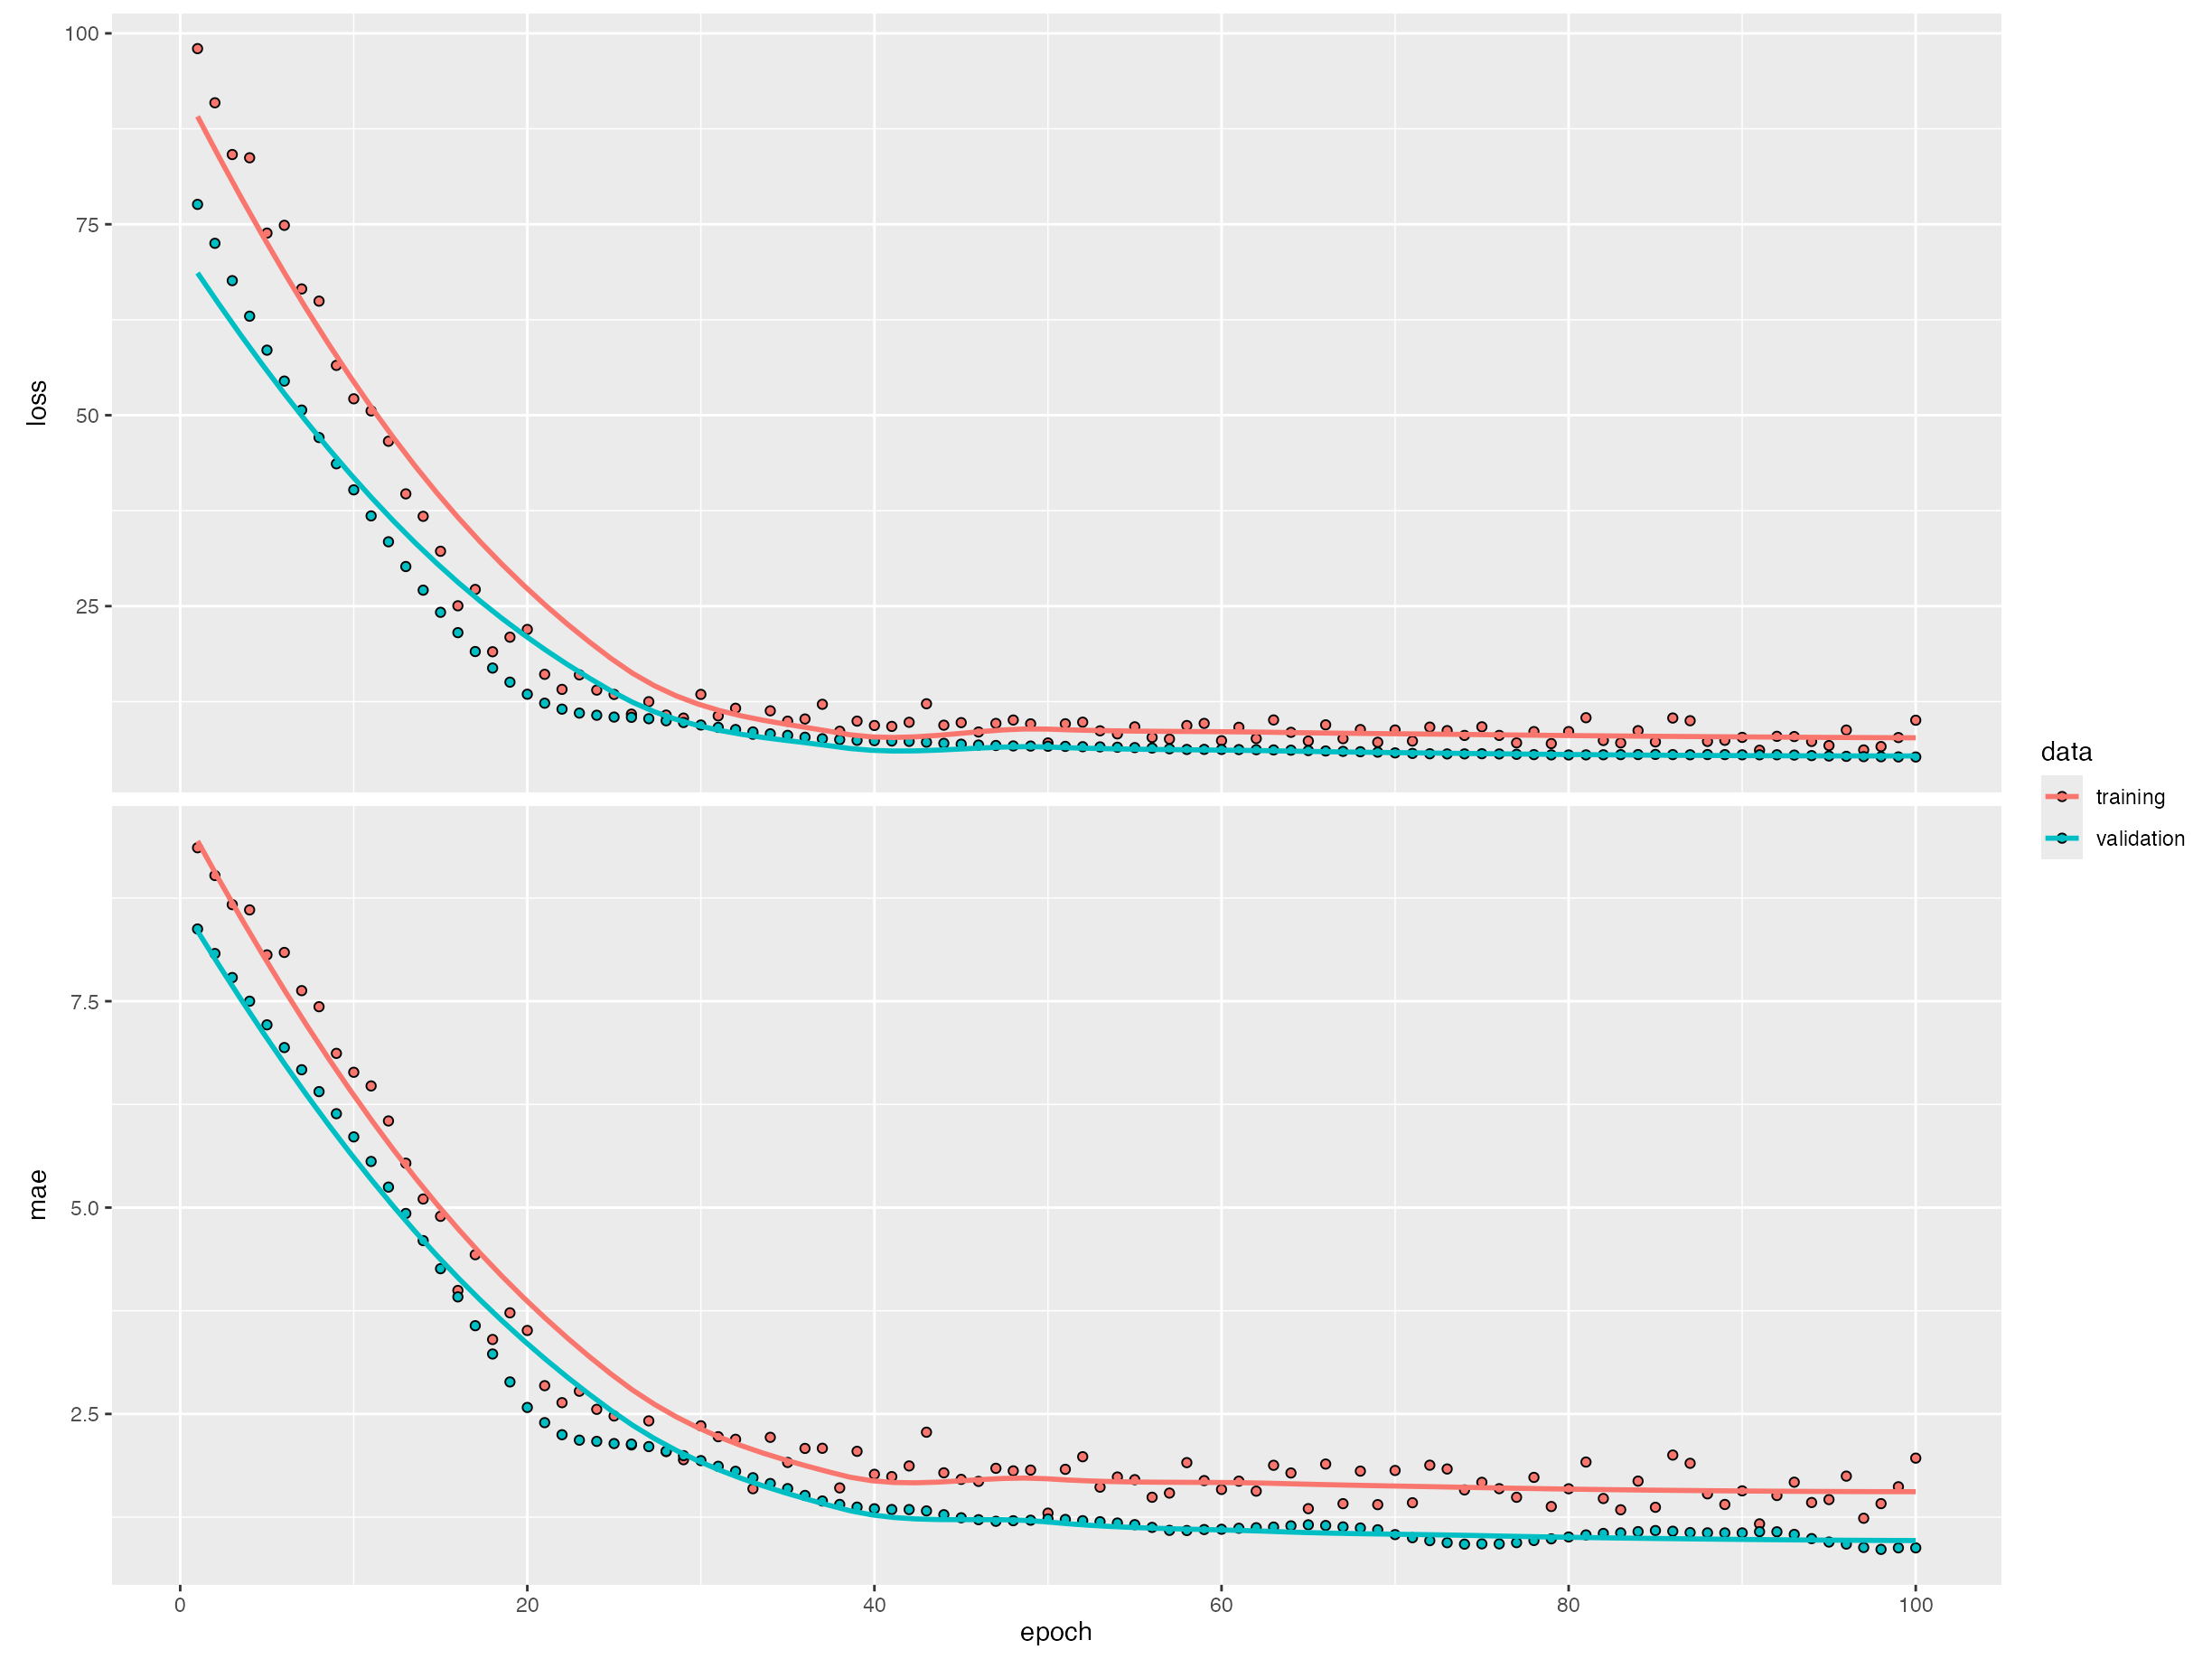

In [147]:
  # Train model with L2 regularization
  history_l2 <- nn_model_l2 %>% fit(
    X_train_scaled, y_train,
    epochs = 100,
    batch_size = 8,
    validation_split = 0.2,
    verbose = 1
  )

  plot(history_l2)

In [148]:
# Evaluate original model
  pred_original <- nn_model %>% predict(X_test_scaled)
  rmse_original <- sqrt(mean((y_test - pred_original)^2))
  mae_original <- mean(abs(y_test - pred_original))

  # Evaluate L2 regularized model
  pred_l2 <- nn_model_l2 %>% predict(X_test_scaled)
  rmse_l2 <- sqrt(mean((y_test - pred_l2)^2))
  mae_l2 <- mean(abs(y_test - pred_l2))

  # Print comparison
  cat("Original Model:\n")
  cat("  RMSE:", rmse_original, "\n")
  cat("  MAE:", mae_original, "\n\n")

  cat("L2 Regularized Model:\n")
  cat("  RMSE:", rmse_l2, "\n")
  cat("  MAE:", mae_l2, "\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Original Model:
  RMSE: 1.383737 
  MAE: 1.06162 

L2 Regularized Model:
  RMSE: 0.6497374 
  MAE: 0.5526421 


In [150]:
models_dir <- "/Users/winniex/Desktop/WDS/Project/Models"                                                                                                         
  if (!dir.exists(models_dir)) {
    dir.create(models_dir, recursive = TRUE)                                                                                                                                                 
  }               

  model_path <- file.path(models_dir, "nn_model_l2_poverty_prediction.keras")
  save_model(nn_model_l2, model_path, overwrite=TRUE)

  cat("Model saved to:", model_path, "\n")

  preproc_path <- file.path(models_dir, "preprocessing_scaler.rds")
  saveRDS(preproc, preproc_path)

  cat("Preprocessing scaler saved to:", preproc_path, "\n")

Model saved to: /Users/winniex/Desktop/WDS/Project/Models/nn_model_l2_poverty_prediction.keras 
Preprocessing scaler saved to: /Users/winniex/Desktop/WDS/Project/Models/preprocessing_scaler.rds 
